---
# Exemple de regroupement de données en apprentissage non supervisé
### Auteur: Pierre Gravel <pierre.gravel@iid.ulaval.ca>
### Institut intelligence et données (IID), Québec, Canada
### License: BSD
---

<p>&nbsp;</p>
<div align="center">
    <img src= "images/kmeans.png"  width="700" />
    <div>
    <font size="1.5">Image Source: https://towardsdatascience.com/how-many-clusters-6b3f220f0ef5//</font>
    </div>
</div>
<p>&nbsp;</p>

Dans ce tutoriel, nous allons voir quelques exemples de regroupement de données appliqués à des images de chiffres. 

## Table des matières
1. Le regroupement de données
   1. Exemple
    2. Méthodes de regroupement des données
2. Exemple de regroupement de données en apprentissage non supervisé
    1. Préparation des données
    2. Affichage des résultats
3. Exercice
4. Conclusion

#### Importation des librairies utilisées.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets, manifold
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import umap

import warnings
warnings.filterwarnings("ignore", message="n_jobs value 1 overridden")

seed = 42
np.random.seed(seed)

%matplotlib inline

## Le regroupement de données

Les bases de données couramment utilisées sont souvent constituées de caractéristiques $X=[x_1, x_2, \cdots, x_N]$ avec une réponse $y$. Dans les problèmes de classification, la réponse $y$ correspond à une classe prédéterminée (p. ex. « voiture » ou « camion »). Ça implique que quelqu'un a mesuré les caractéristiques pour des éléments de types connus.

Il y a une autre classe de problèmes où les éléments ne sont pas connus à l'avance. C'est le regroupement des données (*Data Clustering*). On aimerait savoir si les éléments pour lesquels on a mesuré les caractéristiques $X$ peuvent être ordonnés de façon cohérente afin de révéler un ordre sous-jacent. On cherche à découvrir s'il y a une organisation latente (c.-à-d. cachée) dans celles-ci.

### Méthodes de regroupement des données

Il existe plusieurs
[méthodes de regroupement](https://fr.wikipedia.org/wiki/Partitionnement_de_données) de données.
Les plus connues, qui ne touchent pas à l'apprentissage profond, sont probablement les suivantes:

- les k-moyennes (*K-Means*),
- le mélange de gaussiennes (*gaussian mixtures*),
- le clustering hiérarchique,
- DBSCAN (*density-based spatial clustering of applications with noise*),
- HDBSCAN (*Hierarchical* DBSCAN).

Elles sont toutes basées sur la notion de distance entre les données $X$ dans un espace en N dimensions.
Il existe plusieurs
[façons de mesurer les distances](https://fr.wikipedia.org/wiki/Distance_%28mathématiques%29).
La figure suivante montre les principales; la distance
euclidienne demeure la plus utilisée.

<p>&nbsp;</p>
<div align="center">
    <img src= "./images/distance-metrics.png"  width="500" />
    <div>
    <font size="0.5">Image Source: https://fr.wikipedia.org/wiki/Distance_(mathématiques)/</font>
    </div>
</div>
<p>&nbsp;</p>

Il faut souvent déterminer à l'avance le nombre de groupes de données. Il existe plusieurs façons de le faire.
Les [méthodes suivantes](https://en.wikipedia.org/wiki/Determining_the_number_of_clusters_in_a_data_set)
sont souvent utilisées:

- le coefficient de [silhouette](https://fr.wikipedia.org/wiki/Silhouette_(clustering)) ;
- les critères d'information d'Akaike et bayésien.
  
D'autres méthodes, telles que DBSCAN et HDBSCAN, effectuent les regroupements sans utiliser un nombre prédéterminé de groupes. Elles ont toutefois des paramètres à ajuster qui influent sur le nombre de groupes découverts.

#### Les méthodes de regroupement sont itératives

L'animation suivante montre la méthode de regroupement **K-Means** qui est la plus intuitive
de toutes. On essaie ici de regrouper les données en quatre amas. On initialise aléatoirement
le centre des amas, identifiés par des croix. Ensuite, chaque point est assigné à la croix la
plus proche. Une fois cette étape terminée, on calcule le centre de gravité des points assignés
à chaque croix et on la déplace à cet endroit. On recommence plusieurs fois la même série d'opérations.
Dans la figure, une couleur est associée à chaque amas. Le panneau de droite affiche une métrique
de qualité de regroupement, soit la somme des distances au carré entre chaque croix et les points
qui lui sont associés. Au fil des itérations, les amas sont de mieux en mieux définis et les points
de mieux en mieux assignés aux croix. En conséquence, la somme des distances diminue et finit par
être plus ou moins constante; l'algorithme a alors convergé et le regroupement est terminé. 

<p>&nbsp;</p>
<div align="center">
    <img src= "./images/k-means-in-action.gif"  width="500" />
    <div>
    <font size="0.5">Image Source: https://damminhtien.com/2018/11/11/K-Means-Clustering.html/</font>
    </div>
</div>
<p>&nbsp;</p>

L'animation suivante montre les résultats de regroupement en utilisant l'algorithme **espérance-maximisation (EM)**,
mieux connu sous le nom de mélange de gaussiennes. La différence fondamentale avec la méthode précédente
est que l’algorithme K-Means fait l'hypothèse que les groupes contiennent le même nombre de points et ont
la même distribution isotrope. L’algorithme EM part de la solution K-Means, puis fait les hypothèses suivantes;

- les distributions sont gaussiennes,
- elles peuvent être anisotropes,
- elles peuvent avoir des nombres de points différents.

À chaque itération, la probabilité d'appartenance de chaque point à
chaque amas est calculée, puis on s'en sert pour calculer les nouvelles positions et distributions statistiques
des amas. Les itérations se poursuivent jusqu'à convergence, comme pour la méthode K-Means.

<p>&nbsp;</p>
<div align="center">
    <img src= "./images/em-in-action.gif"  width="500" />
    <div>
    <font size="0.5">Image Source: https://fr.wikipedia.org/wiki/Algorithme_espérance-maximisationfont>
    </div>
</div>
<p>&nbsp;</p>

## Exemples de regroupement de données en apprentissage non supervisé

Nous allons montrer comment effectuer un regroupement de données à partir de la base de
données [**MNIST**](https://en.wikipedia.org/wiki/MNIST_database) qui comprend des images de chiffres de 0 à 9 de
taille $8 \text{ par } 8$.

Nous considérons qu'à chaque image correspond un point dans un espace de dimension 8 × 8 = 64. Au lieu d'essayer de regrouper des points dans un espace de cette dimension, nous allons plutôt projeter les données en 2D à l'aide de différentes méthodes de réduction de la dimensionnalité. 

Nous utiliserons ensuite différentes méthodes de regroupement de données. Les images, une fois regroupées, permettront de délimiter la zone d'influence de chaque classe de chiffre. Cette représentation est souvent utilisée pour comparer diverses méthodes de classification entre elles.

Cette section s'inspire librement de l'[exemple](https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_digits.html)
de Scikit-learn sur le regroupement des données avec la méthode K-Means.

### Préparation des données

#### Exemple 1

In [2]:
# Lecture du jeu de données

n_digits = 10
X, y = datasets.load_digits(return_X_y=True)

Afin de faciliter la classification, les données en 64-D vont être normalisées. Puis, pour les fins de cet exemple, la dimensionnalité des données sera réduite à 2-D avec l'[analyse en composantes principales](https://fr.wikipedia.org/wiki/Analyse_en_composantes_principales) (ACP, PCA en anglais). Enfin, ces données 2-D vont être regroupées en 10 groupes avec la méthode K-Means.

Les trois opérations sont effectuées avec le pipeline de prétraitement suivant:

In [3]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2)),
    ("kmeans", KMeans(n_clusters=n_digits, random_state=seed))
])

Dans cet exemple, on se sert de toutes les caractéristiques $X$ comme ensemble d'entraînement.

In [4]:
pipeline.fit(X)

# Données PCA cohérentes avec KMeans
X_transf = pipeline[:-1].transform(X)

# Calcul de l'étiquette de chaque point
y_pred = pipeline["kmeans"].labels_

On définit une grille dans l'espace des composantes principales $(PC_1, PC_2)$ où l'on va calculer la classe associée à chaque point. Cela va permettre de visualiser la zone d'influence de chacune.

In [5]:
# Grille dans l’espace PCA
h = 0.02

x_min, x_max = X_transf[:, 0].min() - 1, X_transf[:, 0].max() + 1
y_min, y_max = X_transf[:, 1].min() - 1, X_transf[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Prédiction de la classe associée à chaque position $(PC_1, PC_2)$ de la grille.

In [6]:
# Prédiction KMeans sur la grille PCA
Z = pipeline["kmeans"].predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

La figure suivante présente ces informations:

- le centroïde de chaque classe, indiqué par un cercle jaune,
- la zone d'influence de chaque classe, indiquée par une couleur différente,
- le symbole et la position de chaque image du jeu de données

Text(0, 0.5, 'PC$_2$')

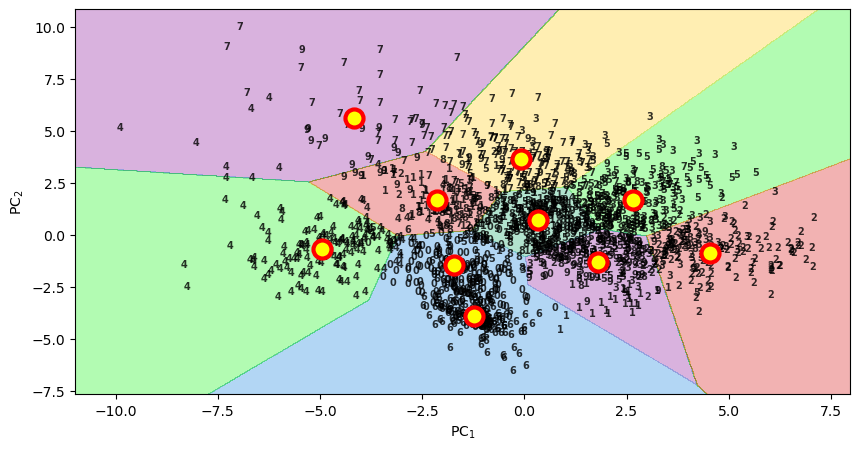

In [7]:
# Affichage
fig, ax = plt.subplots(figsize=(10, 5))
ax.contourf(xx, yy, Z, cmap="nipy_spectral", alpha=0.3)

centroids = pipeline["kmeans"].cluster_centers_
ax.scatter(centroids[:, 0], centroids[:, 1],
           marker="o", s=169, linewidths=3,
           color="yellow", edgecolors="r", zorder=10)

for i in range(X.shape[0]):
    ax.text(X_transf[i, 0], X_transf[i, 1], str(y[i]),
            fontdict={"weight": "bold", "size": 7}, alpha=0.8)

ax.set_xlabel(r"PC$_1$")
ax.set_ylabel(r"PC$_2$")

La figure (étirée pour une meilleure visualisation) montre que les chiffres ne sont pas bien séparés. Il y a un important chevauchement entre les classes. Ce recouvrement rend impossible l'observation claire de la zone colorée délimitant chaque classe. 

La raison en est que l'ACP en 2D ne capture qu’une petite partie de la variance totale (20 à 25 %). Les clusters ne seront donc pas parfaitement séparés.

#### Le coefficient de silhouette

En regroupement de données, on utilise souvent le coefficient de silhouette pour évaluer la qualité d'une partition d'un ensemble de données.

Ce coefficient varie entre -1 (classification la moins bonne) et 1 (classification la meilleure). Plus la silhouette est proche de 1, plus les groupes sont compacts et bien séparés.

Calculons le coefficient de silhouette du regroupement.

In [8]:
print("Silhouette :", silhouette_score(X_transf, y_pred))

Silhouette : 0.3788052258187925


Ce n'est pas très élevé; cela s'explique par le recouvrement observé des classes.

### Exemple 2

Cette fois-ci, on va utiliser la transformation [UMAP](https://en.wikipedia.org/wiki/Nonlinear_dimensionality_reduction#Uniform_manifold_approximation_and_projection) pour réduire la dimensionalité des données, suivi d'un regroupement utilisant les [mélanges de gaussiennes](https://en.wikipedia.org/wiki/EM_algorithm_and_GMM_model).

Afin de faciliter la classification, les données en 64-D vont être normalisées. Puis, pour les fins de cet exemple, la dimensionnalité des données sera réduite à 2-D avec UMAP. Enfin, ces données 2-D vont être regroupées en 10 groupes avec la méthode GMM.

Les trois opérations sont effectuées avec le pipeline de prétraitement suivant:

In [9]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("umap", umap.UMAP(
        n_components=2,
        n_neighbors=30,
        min_dist=0.0,
        metric="euclidean",
        random_state=seed
    )),
    ("gmm", GaussianMixture(
        n_components=10,
        covariance_type="diag",
        random_state=seed
    ))
])

Dans cet exemple, on se sert de toutes les caractéristiques $X$ comme ensemble d'entraînement.

In [10]:
pipeline.fit(X)

# Données UMAP cohérentes avec Gaussian Mixtures
X_transf = pipeline[:-1].transform(X)
y_pred = pipeline["gmm"].predict(X_transf)

#### Affichage des résultats
On définit une grille dans l'espace des composantes principales $(UMAP_1, UMAP_2)$ où l'on va calculer la classe associée à chaque point. Cela va permettre de visualiser la zone d'influence de chacune.

In [11]:
# Grille dans l’espace UMAP
h = 0.02
x_min, x_max = X_transf[:, 0].min() - 1, X_transf[:, 0].max() + 1
y_min, y_max = X_transf[:, 1].min() - 1, X_transf[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

In [12]:
# Prédiction GMM sur la grille UMAP
Z = pipeline["gmm"].predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

Text(0, 0.5, 'UMAP$_2$')

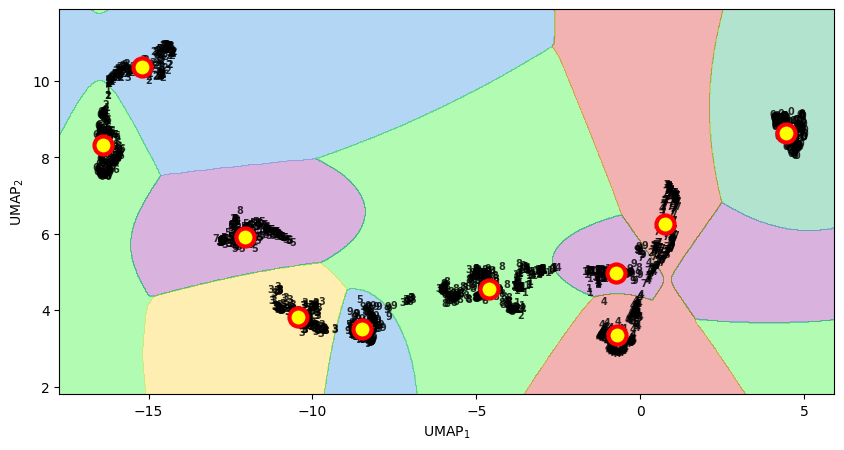

In [13]:
# Affichage
fig, ax = plt.subplots(figsize=(10, 5))
ax.contourf(xx, yy, Z, cmap="nipy_spectral", alpha=0.3)

centroids = pipeline["gmm"].means_
ax.scatter(centroids[:, 0], centroids[:, 1],
           marker="o", s=169, linewidths=3,
           color="yellow", edgecolors="r", zorder=10)

for i in range(X.shape[0]):
    ax.text(X_transf[i, 0], X_transf[i, 1], str(y[i]),
            fontdict={"weight": "bold", "size": 7}, alpha=0.8)

ax.set_xlabel(r"UMAP$_1$")
ax.set_ylabel(r"UMAP$_2$")

La figure (étirée pour une meilleure visualisation) montre que les chiffres sont très bien séparés ! Il y a peu de recouvrement entre les classes. La zone colorée délimitant chaque classe est plus visible, mais elle est compliquée par le fait que chaque groupe présente une distribution gaussienne différente des autres (plus ou moins étalée et orientée différemment).

Calculons la silhouette du regroupement.

In [14]:
print("Silhouette :", silhouette_score(X_transf, y_pred))

Silhouette : 0.6268385052680969


La silhouette est plus près de +1, ce qui indique un meilleur regroupement des données, comme on le sait déjà.

**Remarque**: expérimentez avec d'autres méthodes de réduction de la dimensionnalité et de regroupement de données. 